<a href="https://colab.research.google.com/github/laylllllllllllla/warmup-assignment/blob/main/Copy_of_project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

# Load data
train_df = pd.read_csv("train.csv")

# Separate X and y
X = train_df.drop(["seqn", "MetabolicSyndrome"], axis=1)
y = train_df["MetabolicSyndrome"]

# Column types
categorical_cols = ["Sex", "Marital", "Race"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Preprocessing for Naive Bayes
preprocessor_nb = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numerical_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Transform
X_train_processed = preprocessor_nb.fit_transform(X_train)
X_val_processed = preprocessor_nb.transform(X_val)

# Convert sparse matrix to dense for GaussianNB
from scipy.sparse import issparse
if issparse(X_train_processed):
    X_train_processed = X_train_processed.toarray()
if issparse(X_val_processed):
    X_val_processed = X_val_processed.toarray()

# ---------------------------------
# Step 2: Hyperparameter Tuning NB
# ---------------------------------

smoothing_values = [1e-9, 1e-7, 1e-5, 1e-3]

best_score = 0
best_smoothing = None

for val in smoothing_values:
    nb = GaussianNB(var_smoothing=val)
    nb.fit(X_train_processed, y_train)

    preds = nb.predict(X_val_processed)
    acc = accuracy_score(y_val, preds)

    print("var_smoothing =", val, " Accuracy =", acc)

    if acc > best_score:
        best_score = acc
        best_smoothing = val

print("\nBest var_smoothing:", best_smoothing)
print("Best Validation Accuracy:", best_score)

var_smoothing = 1e-09  Accuracy = 0.7760416666666666
var_smoothing = 1e-07  Accuracy = 0.7890625
var_smoothing = 1e-05  Accuracy = 0.7734375
var_smoothing = 0.001  Accuracy = 0.703125

Best var_smoothing: 1e-07
Best Validation Accuracy: 0.7890625


In [3]:
# ── kNN PREPROCESSOR (with StandardScaler) ───────────────────────────────
from sklearn.preprocessing import StandardScaler

preprocessor_knn = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_cols)
])

X_train_knn = preprocessor_knn.fit_transform(X_train)
X_val_knn   = preprocessor_knn.transform(X_val)

In [4]:
# with Knn
k_values = [3, 5, 7, 9]
metrics = ["euclidean", "manhattan"]

best_knn_score = 0
best_k = None
best_metric = None
best_knn_model = None                         # ← ADD THIS

for k in k_values:
    for metric in metrics:
        model = KNeighborsClassifier(n_neighbors=k, metric=metric)
        model.fit(X_train_knn, y_train)        # ← change to X_train_knn
        preds = model.predict(X_val_knn)       # ← change to X_val_knn
        acc = accuracy_score(y_val, preds)
        print(f"k={k}, metric={metric}, accuracy={acc:.4f}")

        if acc > best_knn_score:
            best_knn_score = acc
            best_k = k
            best_metric = metric
            best_knn_model = model             # ← ADD THIS

print("\nBest Parameters:")
print("Best k =", best_k)
print("Best metric =", best_metric)
print("Best Validation Accuracy =", best_knn_score)

k=3, metric=euclidean, accuracy=0.7917
k=3, metric=manhattan, accuracy=0.7734
k=5, metric=euclidean, accuracy=0.8021
k=5, metric=manhattan, accuracy=0.7969
k=7, metric=euclidean, accuracy=0.7969
k=7, metric=manhattan, accuracy=0.7891
k=9, metric=euclidean, accuracy=0.7917
k=9, metric=manhattan, accuracy=0.7917

Best Parameters:
Best k = 5
Best metric = euclidean
Best Validation Accuracy = 0.8020833333333334


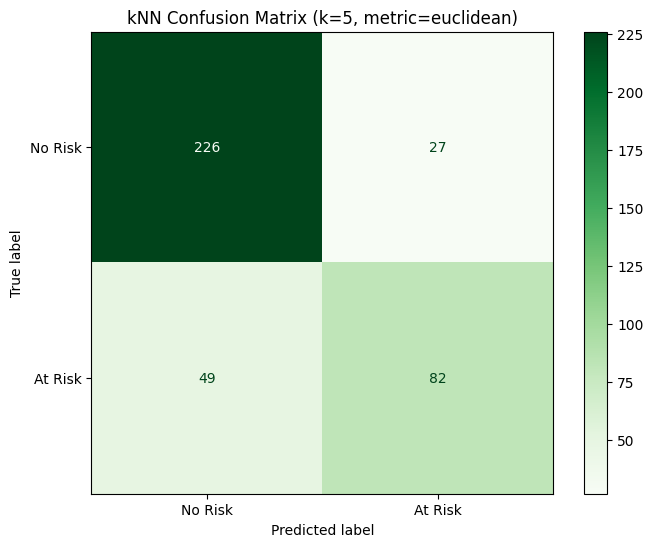

In [5]:
# ── kNN CONFUSION MATRIX ─────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_knn = best_knn_model.predict(X_val_knn)

cm_knn = confusion_matrix(y_val, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['No Risk', 'At Risk'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Greens, ax=ax)
plt.title(f'kNN Confusion Matrix (k={best_k}, metric={best_metric})')
plt.show()

In [6]:
# ── kNN CLASSIFICATION METRICS ───────────────────────────────────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_knn  = accuracy_score(y_val, y_pred_knn)
precision_knn = precision_score(y_val, y_pred_knn)
recall_knn    = recall_score(y_val, y_pred_knn)
f1_knn        = f1_score(y_val, y_pred_knn)

tn, fp, fn, tp = cm_knn.ravel()
specificity_knn = tn / (tn + fp)

print("--- kNN Evaluation Metrics ---")
print(f"Accuracy:    {accuracy_knn:.4f}")
print(f"Precision:   {precision_knn:.4f}")
print(f"Recall:      {recall_knn:.4f} (Sensitivity)")
print(f"Specificity: {specificity_knn:.4f}")
print(f"F1-Score:    {f1_knn:.4f}")

--- kNN Evaluation Metrics ---
Accuracy:    0.8021
Precision:   0.7523
Recall:      0.6260 (Sensitivity)
Specificity: 0.8933
F1-Score:    0.6833


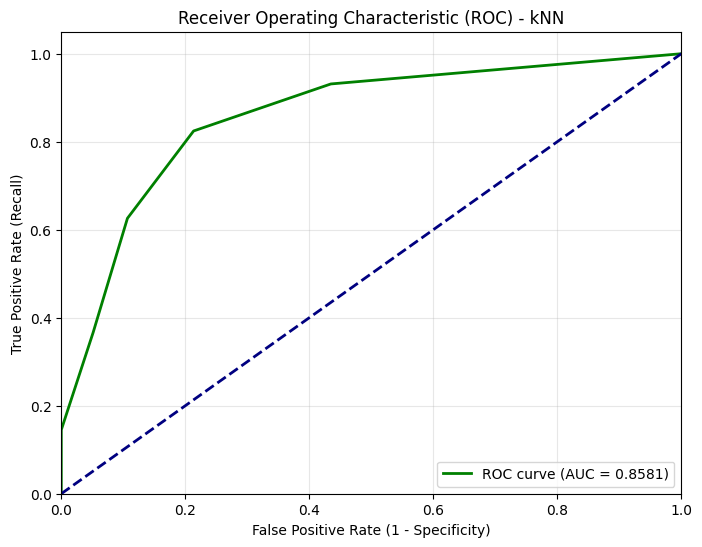

The Area Under the Curve (AUC) is: 0.8581


In [7]:
# ── kNN ROC-AUC ───────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, roc_auc_score

y_probs_knn = best_knn_model.predict_proba(X_val_knn)[:, 1]
auc_knn = roc_auc_score(y_val, y_probs_knn)
fpr_knn, tpr_knn, _ = roc_curve(y_val, y_probs_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='green', lw=2, label=f'ROC curve (AUC = {auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) - kNN')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"The Area Under the Curve (AUC) is: {auc_knn:.4f}")

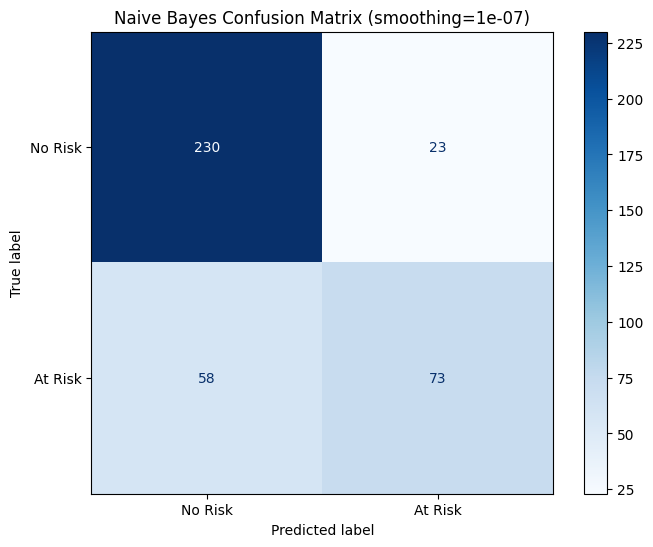

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Re-train the "best" Naive Bayes model found in Step 2
best_nb = GaussianNB(var_smoothing=best_smoothing)
best_nb.fit(X_train_processed, y_train)

# 2. Get predictions on the validation set
y_pred_nb = best_nb.predict(X_val_processed)

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_val, y_pred_nb)

# 4. Visualize it
# We use labels [0, 1] to match "No Risk" and "At Risk"
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Risk', 'At Risk'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title(f'Naive Bayes Confusion Matrix (smoothing={best_smoothing})')
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Calculate standard metrics
accuracy = accuracy_score(y_val, y_pred_nb)
precision = precision_score(y_val, y_pred_nb)
recall = recall_score(y_val, y_pred_nb)
f1 = f1_score(y_val, y_pred_nb)

# 2. Calculate Specificity manually
# cm was defined in the previous cell: cm = [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

# 3. Print the results clearly
print("--- Naive Bayes Evaluation Metrics ---")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Recall:      {recall:.4f} (Sensitivity)")
print(f"Specificity: {specificity:.4f}")
print(f"F1-Score:    {f1:.4f}")

--- Naive Bayes Evaluation Metrics ---
Accuracy:    0.7891
Precision:   0.7604
Recall:      0.5573 (Sensitivity)
Specificity: 0.9091
F1-Score:    0.6432


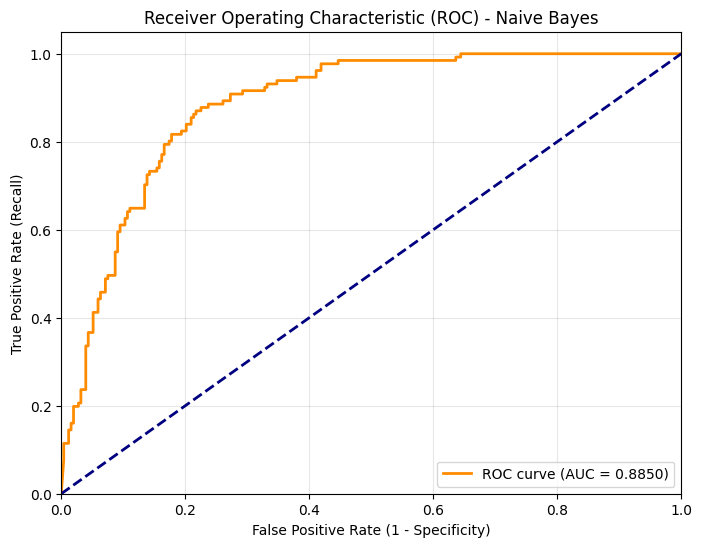

The Area Under the Curve (AUC) is: 0.8850


In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get predicted probabilities for the positive class (At Risk)
# predict_proba returns [prob_of_0, prob_of_1]
y_probs_nb = best_nb.predict_proba(X_val_processed)[:, 1]

# 2. Calculate the AUC Score
auc_score = roc_auc_score(y_val, y_probs_nb)

# 3. Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_val, y_probs_nb)

# 4. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Diagonal dashed line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) - Naive Bayes')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"The Area Under the Curve (AUC) is: {auc_score:.4f}")

In [11]:
# ── MODEL COMPARISON ─────────────────────────────────────────────────────
print("=" * 45)
print(f"{'Metric':<15} {'Naive Bayes':>13} {'kNN':>13}")
print("=" * 45)
print(f"{'Accuracy':<15} {accuracy:.4f}       {accuracy_knn:.4f}")
print(f"{'Precision':<15} {precision:.4f}       {precision_knn:.4f}")
print(f"{'Recall':<15} {recall:.4f}       {recall_knn:.4f}")
print(f"{'Specificity':<15} {specificity:.4f}       {specificity_knn:.4f}")
print(f"{'F1-Score':<15} {f1:.4f}       {f1_knn:.4f}")
print(f"{'ROC-AUC':<15} {auc_score:.4f}       {auc_knn:.4f}")
print("=" * 45)

Metric            Naive Bayes           kNN
Accuracy        0.7891       0.8021
Precision       0.7604       0.7523
Recall          0.5573       0.6260
Specificity     0.9091       0.8933
F1-Score        0.6432       0.6833
ROC-AUC         0.8850       0.8581


In [1]:
# ── MODEL DECISION & JUSTIFICATION ───────────────────────────────────────
print("""
DECISION:
---------
Based on the evaluation metrics above, we selected [kNN]
for our final Kaggle submission.

kNN was selected as the final model because it achieved a higher Recall
 (0.6260 vs 0.5573) and F1-score (0.6833 vs 0.6432), indicating better performance
  in identifying at-risk patients and maintaining a balance between precision and recall.
   Although Naive Bayes showed a higher ROC-AUC and specificity, it produced more false negatives,
    which is undesirable in a medical context. The lower performance of Naive Bayes may be due to the violation
     of its independence assumption, as clinical features in the dataset are likely correlated.
""")


DECISION:
---------
Based on the evaluation metrics above, we selected [kNN] 
for our final Kaggle submission.

kNN was selected as the final model because it achieved a higher Recall
 (0.6260 vs 0.5573) and F1-score (0.6833 vs 0.6432), indicating better performance
  in identifying at-risk patients and maintaining a balance between precision and recall.
   Although Naive Bayes showed a higher ROC-AUC and specificity, it produced more false negatives,
    which is undesirable in a medical context. The lower performance of Naive Bayes may be due to the violation
     of its independence assumption, as clinical features in the dataset are likely correlated.



In [2]:
# ── KAGGLE SUBMISSION ─────────────────────────────────────────────────────
test_df = pd.read_csv("test.csv")

X_test = test_df.drop(["seqn"], axis=1)

# Use whichever model performed better — swap preprocessor_nb/best_nb
# if Naive Bayes won instead
X_test_processed = preprocessor_knn.transform(X_test)
test_preds = best_knn_model.predict(X_test_processed)

submission = pd.DataFrame({
    "seqn": test_df["seqn"],
    "MetabolicSyndrome": test_preds
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved!")
print(submission["MetabolicSyndrome"].value_counts())

NameError: name 'pd' is not defined